* ## Angélica Vanegas C.C 1000290572


# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e+e^x(2-x)-x
\end{equation}

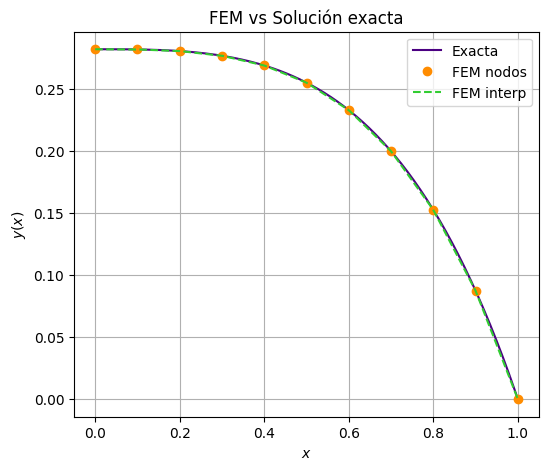

In [43]:
#@title Solución de la ecuación matricial $Ay=b$

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Parámetros del intervalo

N = 11
a, b_dom = 0.0, 1.0
h = (b_dom - a)/(N-1)

# Malla
xi = np.linspace(a, b_dom, N)

# Matriz A
A = np.zeros((N, N))

for i in range(1, N):
    A[i-1, i-1] += 1/h
    A[i-1, i]   += -1/h
    A[i, i-1]   += -1/h
    A[i, i]     += 1/h

# Definición de la funciones base phi's

def lin1(x, x1, x2):
    return (x - x1)/(x2 - x1)

def lin2(x, x1, x2):
    return (x2 - x)/(x2 - x1)

# Función de la ecuacioón diferencial

def f(x):
    return x * np.exp(x)

# Vector b

b_vec = np.zeros(N)

for i in range(1, N):
    x1, x2 = xi[i-1], xi[i]

    b_vec[i-1] += integrate.quad(lambda x: f(x)*lin2(x, x1, x2), x1, x2)[0]
    b_vec[i]   += integrate.quad(lambda x: f(x)*lin1(x, x1, x2), x1, x2)[0]


# Condiciones de frontera para b

ya = 3 - np.exp(1)
yb = 0.0

# Ajustar b con las ecuaciones lineales que salen en el sistema A*y
for i in range(N):
    b_vec[i] -= A[i,0] * ya
    b_vec[i] -= A[i,N-1] * yb

# Imponer las condiciones de frontera para la matriz A (Dirichlet)
A[:,0] = 0
A[0,:] = 0
A[0,0] = 1

A[:,N-1] = 0
A[N-1,:] = 0
A[N-1,N-1] = 1

# Ajustar b en fronteras
b_vec[0] = ya
b_vec[N-1] = yb

# Resolver sistema
sol = np.linalg.solve(A, b_vec)

# Interpolación para la solución

x_new = np.linspace(0,1,200)
y_new = np.interp(x_new, xi, sol)

# Solución exacta, la solución analítica de la ecuación diferencial tenían un signo erróneo


def exact(x):
    return (2-x)*np.exp(x) - x + 1 - np.exp(1)


# Gráfica
plt.figure(figsize=(6,5))
plt.plot(x_new, exact(x_new), color = "indigo", label='Exacta')
plt.plot(xi, sol, 'o', color = "darkorange", label='FEM nodos')
plt.plot(x_new, y_new, '--', color = "limegreen", label='FEM interp')

plt.xlabel('$x$')
plt.ylabel('$y(x)$')
plt.title('FEM vs Solución exacta')
plt.legend()
plt.grid()
plt.show()

### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

In [44]:
#@title Solución, repetimos el método para esta ecuación

N = 11
a, b = 0.0, 1.0
h = (b - a)/(N - 1)

In [45]:
x = np.linspace(a, b, N)

def phi1(x, x1, x2):
    return (x2 - x)/(x2 - x1)

def phi2(x, x1, x2):
    return (x - x1)/(x2 - x1)

A = np.zeros((N, N))

for i in range(1, N):
    A[i-1,i-1] += 1/h
    A[i-1,i]   += -1/h
    A[i,i-1]   += -1/h
    A[i,i]     += 1/h

b = np.zeros(N)

def f(x):
    return np.sin(np.pi * x)

for i in range(1, N):
    x1, x2 = x[i-1], x[i]

    b[i-1] += integrate.quad(lambda xi: f(xi)*phi1(xi, x1, x2), x1, x2)[0]
    b[i]   += integrate.quad(lambda xi: f(xi)*phi2(xi, x1, x2), x1, x2)[0]

# Matriz
A[0,:] = 0
A[0,0] = 1

A[-1,:] = 0
A[-1,-1] = 1

# Vector
b[0] = 0
b[-1] = 0


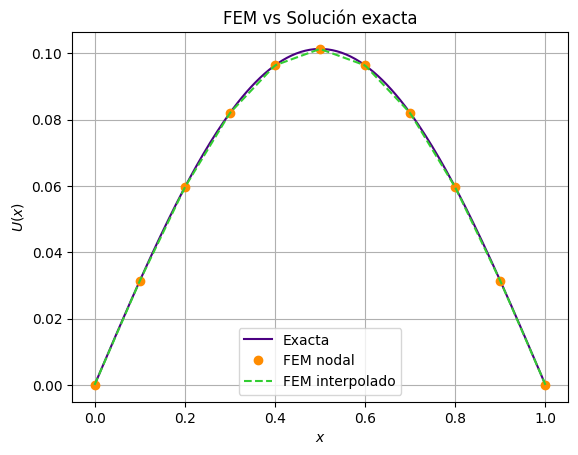

In [47]:
# Solucion de la ecuación matricial

u = np.linalg.solve(A, b)
x_fine = np.linspace(0,1,200)
u_interp = np.interp(x_fine, x, u)

def exact(x):
    return (1/np.pi**2)*np.sin(np.pi*x)

plt.plot(x_fine, exact(x_fine), color = "indigo", label= "Exacta")
plt.plot(x, u, "o", color = "darkorange",label="FEM nodal")
plt.plot(x_fine, u_interp, "--", color = "limegreen", label="FEM interpolado")
plt.title("FEM vs Solución exacta")
plt.xlabel("$x$")
plt.ylabel("$U(x)$")
plt.legend()
plt.grid()
plt.show()